In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import joblib

In [69]:
df = pd.read_csv("Salary_Data.csv")

In [70]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [71]:
df.isnull().sum()

Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64

In [72]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
370     True
371    False
372     True
373     True
374     True
Length: 375, dtype: bool

In [73]:
df = df.dropna()

In [74]:
df.isnull().sum()

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64

In [75]:
df.info()

<class 'pandas.DataFrame'>
Index: 373 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    str    
 2   Education Level      373 non-null    str    
 3   Job Title            373 non-null    str    
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), str(3)
memory usage: 20.4 KB


In [76]:
df.describe()

,Age,Years of Experience,Salary
count,373.000000,373.000000,373.000000
mean,37.431635,10.030831,100577.345845
std,7.069073,6.557007,48240.013482
min,23.000000,0.000000,350.000000
25%,31.000000,4.000000,55000.000000
50%,36.000000,9.000000,95000.000000
75%,44.000000,15.000000,140000.000000
max,53.000000,25.000000,250000.000000


In [77]:
df = df.drop_duplicates()

In [78]:
df.shape

(324, 6)

In [79]:
df.duplicated().sum()

np.int64(0)

In [80]:
df.columns

Index(['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience',
       'Salary'],
      dtype='str')

In [81]:
df = pd.get_dummies(df, drop_first=True)

In [82]:
X = df.drop("Salary", axis=1)
y = df["Salary"]

In [83]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [84]:
print(X_test)
print(y_test)
print(X_train)
print(y_train)

      Age  Years of Experience  Gender_Male  Education Level_Master's  \
132  40.0                 12.0        False                      True   
108  41.0                 14.0        False                      True   
137  30.0                  4.0        False                     False   
9    38.0                 10.0         True                     False   
181  37.0                  9.0         True                      True   
..    ...                  ...          ...                       ...   
104  39.0                 13.0        False                      True   
233  35.0                  8.0         True                     False   
60   51.0                 23.0        False                      True   
94   33.0                  7.0         True                     False   
278  36.0                  8.0         True                     False   

     Education Level_PhD  Job Title_Accountant  \
132                False                 False   
108                Fals

In [85]:
df.describe()

,Age,Years of Experience,Salary
count,324.000000,324.000000,324.000000
mean,37.382716,10.058642,99985.648148
std,7.185844,6.650470,48652.271440
min,23.000000,0.000000,350.000000
25%,31.000000,4.000000,55000.000000
50%,36.500000,9.000000,95000.000000
75%,44.000000,16.000000,140000.000000
max,53.000000,25.000000,250000.000000


In [86]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [87]:
predictions = model.predict(X_test)

In [88]:
print(predictions)

[112480.25810174 111855.62707287  72639.85758158 118709.71545814
 109671.11492766 102114.14642216  73514.65905771  60974.06167598
 174586.55741817  45751.44021683  40345.20405791 137834.913982
 100836.36846176 140719.7167777   86473.84640247 178062.79586679
 111830.50656818 108483.84772202  67019.40100372  48709.71545814
  99987.49341854  51455.96057936  76982.53619903  55375.51136374
 167150.72876199  98882.83543058 146312.20221421 140123.22258061
 169162.64951216  50297.4629937  108527.02991853 172226.9639856
 106898.23453826 143743.05518004 154038.37614941  68621.06616023
  75409.42959672  99867.33899472  95215.9118839   33290.91085733
  97702.25297673  70071.79507931 109496.93827621  76970.02961757
  65729.11646186  45164.45970252 124374.21084721  45254.34489828
 130111.7667813   90873.23326645 147010.00131956  64451.33850145
  58132.57679743 109198.56181286 100405.72326305  80425.40017743
  87598.81832588  50902.05397947  60316.74029343 122904.34712321
 109542.09262908  86290.2845

In [89]:
comparison = pd.DataFrame({
    "Actual Price": y_test,
    "predicted Price": predictions.round(2)
})

In [90]:
print(comparison)

     Actual Price  predicted Price
132      100000.0        112480.26
108      100000.0        111855.63
137       50000.0         72639.86
9        110000.0        118709.72
181      105000.0        109671.11
..            ...              ...
104       80000.0        109542.09
233       85000.0         86290.28
60       170000.0        181497.30
94        75000.0         71270.44
278       95000.0        114621.60

[65 rows x 2 columns]


In [91]:
comparison.head()

,Actual Price,predicted Price
132,100000.0,112480.26
108,100000.0,111855.63
137,50000.0,72639.86
9,110000.0,118709.72
181,105000.0,109671.11


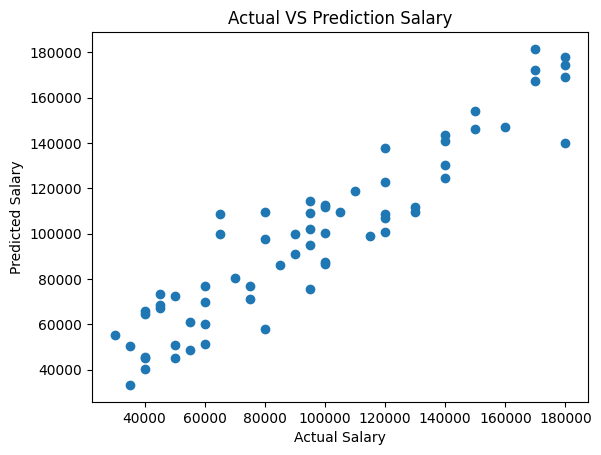

In [92]:
plt.scatter(y_test, predictions)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual VS Prediction Salary")
plt.show()

In [93]:
r2_score(y_test, predictions)

0.8670436880629651

In [94]:
mse = mean_squared_error(y_test, predictions)
print(mse)

251259107.50638214


In [95]:
rmse = np.sqrt(mse)
print(rmse)

15851.154768860915
